# Level 5: Simulation and Optimization

**Project:** HydroSense-Kenya  
**Level:** 5 of 6

---

## Objective

This level combines components from other levels into a complete scientific computing workflow. The HydroSense system must continuously answer: **What will happen to soil moisture tomorrow?**. 

To answer this question we use numerical simulation techniques.

The notebook demonstrates:

1. Evapotranspiration modelling.
2. Water balance modelling.
3. Euler simulation.
4. Runge-Kutta (RK4) simulation.
5. Comparison of numerical methods.

These techniques form the computational core of an intelligent irrigation system.

---

## Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulation import (
    calculate_et,
    compute_drainage,
    water_balance,
    simulate_euler,
    simulate_rk4
)

plt.style.use("default")

## Loading data

In [2]:
weather = pd.read_csv(
    "../data/processed/weather_daily_cleaned.csv"
)

soil = pd.read_csv(
    "../data/processed/soil_sensor_data_cleaned.csv"
)

crop = pd.read_csv(
    "../data/processed/crop_zone_parameters_cleaned.csv"
)

weather["date"] = pd.to_datetime(weather["date"])

print("Weather Shape:", weather.shape)
print("Soil Shape:", soil.shape)
print("Crop Shape:", crop.shape)

Weather Shape: (28, 6)
Soil Shape: (89, 7)
Crop Shape: (3, 7)


## Understanding Water Balance

HydroSense estimates future soil moisture using a water balance equation.

Soil moisture changes because of:

#### Inputs

- Rainfall
- Irrigation

#### Outputs

- Evapotranspiration (ET)
- Drainage

Mathematically:

$$
\Delta S = Rainfall + Irrigation - ET - Drainage
$$

where:

- S = soil moisture
- ET = evapotranspiration

This equation forms the basis of every simulation performed by HydroSense.

In [3]:
sample_et = calculate_et(
    temperature=24,
    wind_speed=3,
    solar_index=0.8,
    humidity=70
)

print(f"Estimated ET = {sample_et:.3f}")

Estimated ET = 4.100


### Evapotranspiration

Evapotranspiration represents water loss from:

1. Soil evaporation.
2. Plant transpiration.

A larger ET value means:

- Faster moisture depletion.
- Increased irrigation demand.
- Greater water consumption.

HydroSense calculates ET daily before updating moisture levels.

In [4]:
drainage = compute_drainage(
    moisture=50,
    field_capacity=40,
    drainage_coeff=0.3
)

print("Drainage =", drainage)

Drainage = 3.0


In [5]:
new_moisture = water_balance(
    moisture=35,
    rainfall=8,
    irrigation=5,
    evapotranspiration=sample_et,
    drainage=2
)

print("Updated Moisture =", round(new_moisture, 2))

Updated Moisture = 41.9


### Why Numerical Simulation?

A single water balance calculation only predicts one day. Farmers require forecasts extending over many days. Numerical simulation repeatedly applies the water balance equation to estimate future soil moisture.

HydroSense uses this capability to:

- Predict moisture shortages.
- Schedule irrigation.
- Reduce water wastage.
- Prevent crop stress.

---

## Euler Method Simulation

The Euler Method is the simplest numerical integration technique.

At each timestep:

1. Compute ET.
2. Compute drainage.
3. Update moisture.
4. Move to the next day.

Advantages:

- Fast
- Easy to implement

Disadvantages:

- Accumulates numerical error over long periods.

Nevertheless, Euler remains an important baseline method in Scientific Computing.

In [6]:
# Determine the largest number of complete observations available
days = weather[
    [
        "rainfall_mm",
        "temperature_c",
        "wind_speed_mps",
        "solar_index",
        "humidity_pct"
    ]
].dropna().shape[0]

print(f"Running simulation for {days} days.")

rainfall = weather["rainfall_mm"].iloc[:days].to_numpy()
temp = weather["temperature_c"].iloc[:days].to_numpy()
wind = weather["wind_speed_mps"].iloc[:days].to_numpy()
solar = weather["solar_index"].iloc[:days].to_numpy()
humidity = weather["humidity_pct"].iloc[:days].to_numpy()

# No irrigation applied during this demonstration
irrigation = np.zeros(days)

Running simulation for 28 days.


In [7]:
euler_result = simulate_euler(
    initial=30,
    rainfall=rainfall,
    irrigation=irrigation,
    temp=temp,
    wind=wind,
    solar=solar,
    humidity=humidity,
    field_capacity=40,
    drainage_coeff=0.25
)

euler_result[:10]

array([30.        , 29.4165    , 27.7875    , 26.643     , 24.4945    ,
       44.5635    , 39.638125  , 37.111625  , 41.74965948, 37.61024461])

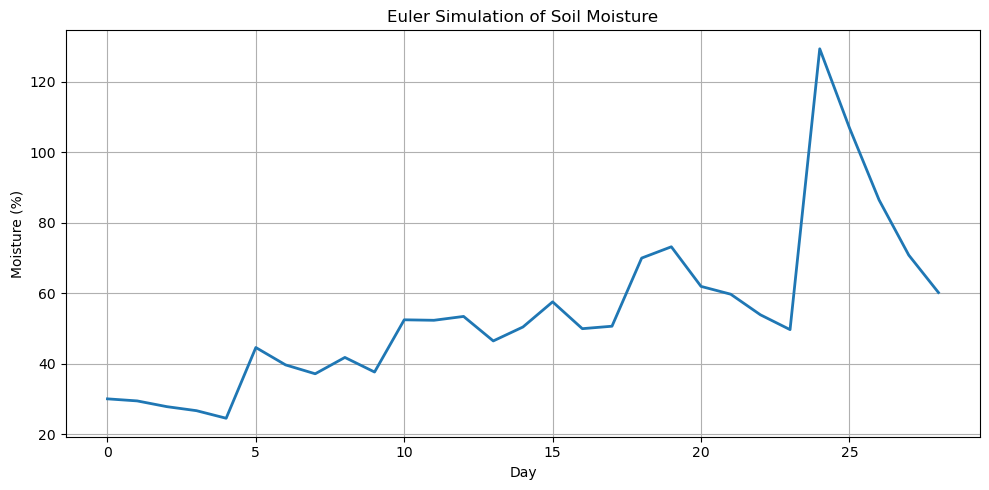

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    euler_result,
    linewidth=2
)

plt.title("Euler Simulation of Soil Moisture")
plt.xlabel("Day")
plt.ylabel("Moisture (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

### Euler Interpretation

The graph shows how soil moisture evolves over time. 

Notice that moisture:

- Increases after rainfall.
- Decreases during dry periods.
- Is reduced by ET and drainage losses.

This behaviour closely resembles real agricultural systems. 

---

## Runge-Kutta (RK4) Simulation

The fourth-order Runge-Kutta method improves upon Euler. Rather than estimating moisture change using a single slope, RK4 evaluates several intermediate slopes and combines them.

Advantages:

- Higher accuracy.
- Better stability.
- Reduced accumulated error.

RK4 is widely used in engineering and scientific modelling.

In [9]:
rk4_result = simulate_rk4(
    initial=30,
    rainfall=rainfall,
    irrigation=irrigation,
    temp=temp,
    wind=wind,
    solar=solar,
    humidity=humidity,
    field_capacity=40,
    drainage_coeff=0.25
)

rk4_result[:10]

array([30.        , 29.4165    , 27.7875    , 26.643     , 24.4945    ,
       44.37335417, 40.0576103 , 37.52870987, 42.07646334, 38.26915542])

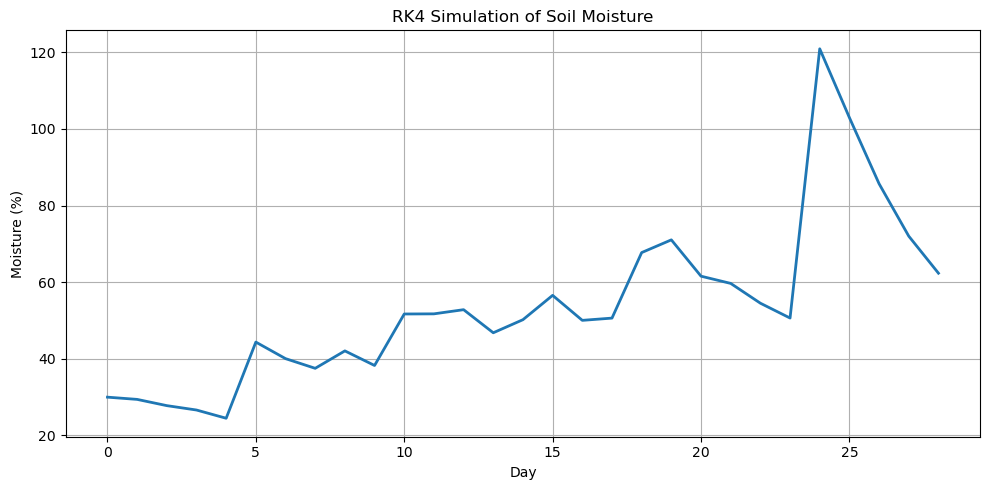

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    rk4_result,
    linewidth=2
)

plt.title("RK4 Simulation of Soil Moisture")
plt.xlabel("Day")
plt.ylabel("Moisture (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

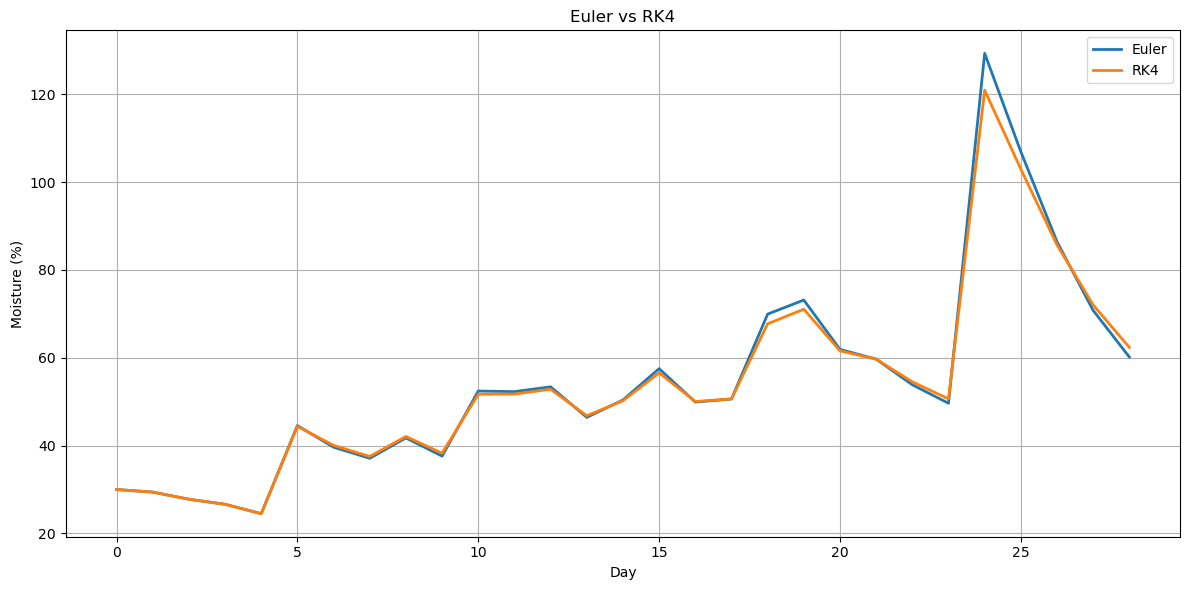

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    euler_result,
    label="Euler",
    linewidth=2
)

plt.plot(
    rk4_result,
    label="RK4",
    linewidth=2
)

plt.title("Euler vs RK4")
plt.xlabel("Day")
plt.ylabel("Moisture (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
comparison = pd.DataFrame({
    "Euler": euler_result,
    "RK4": rk4_result
})

comparison["Difference"] = (
    comparison["RK4"]
    - comparison["Euler"]
)

comparison.head(10)

,Euler,RK4,Difference
0,30.000000,30.000000,0.000000
1,29.416500,29.416500,0.000000
2,27.787500,27.787500,0.000000
3,26.643000,26.643000,0.000000
4,24.494500,24.494500,0.000000
5,44.563500,44.373354,-0.190146
6,39.638125,40.057610,0.419485
7,37.111625,37.528710,0.417085
8,41.749659,42.076463,0.326804
9,37.610245,38.269155,0.658911


### Numerical Method Comparison

Both methods model the same physical process.

However:

#### Euler

- Simpler
- Faster
- Lower accuracy

#### RK4

- More computational work
- Higher accuracy
- Better long-term stability

For real-world irrigation systems, RK4 generally provides more reliable predictions when simulations extend over long periods. In HydroSense, accurate moisture prediction directly affects irrigation decisions, making numerical accuracy highly valuable. 

---

## Monte Carlo Rainfall Simulation

Rainfall is inherently uncertain. Rather than relying on a single weather forecast, HydroSense evaluates hundreds (or thousands) of possible rainfall scenarios using **Monte Carlo Simulation**. Each simulation produces a different possible future based on the historical rainfall distribution.

This allows the irrigation controller to:

- estimate risk,
- prepare for dry periods,
- avoid unnecessary irrigation during wet periods.

In [13]:
from src.simulation import monte_carlo_rainfall

In [14]:
mean_rain = weather["rainfall_mm"].mean()
std_rain  = weather["rainfall_mm"].std()

print(f"Mean rainfall : {mean_rain:.2f} mm/day")
print(f"Std deviation : {std_rain:.2f} mm/day")

Mean rainfall : 8.85 mm/day
Std deviation : 16.59 mm/day


In [15]:
rainfall_samples = monte_carlo_rainfall(
    mean=mean_rain,
    std=std_rain,
    n_days=30,
    n_scenarios=1000,
    seed=42
)

print(rainfall_samples.shape)

(1000, 30)


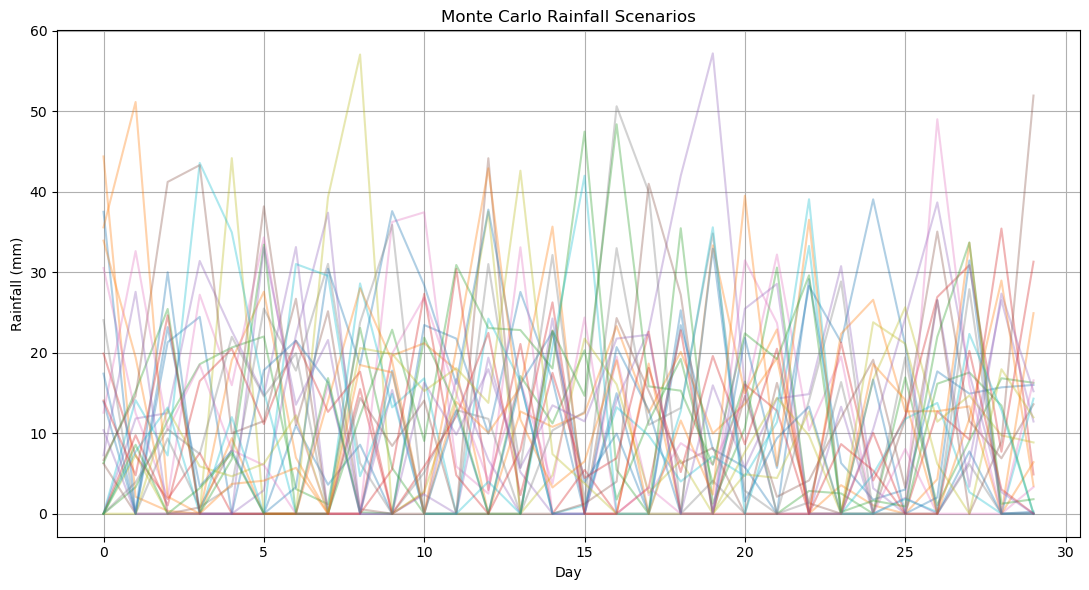

In [16]:
plt.figure(figsize=(11,6))

for i in range(25):
    plt.plot(
        rainfall_samples[i],
        alpha=0.35
    )

plt.title("Monte Carlo Rainfall Scenarios")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")
plt.grid(True)

plt.tight_layout()
plt.show()

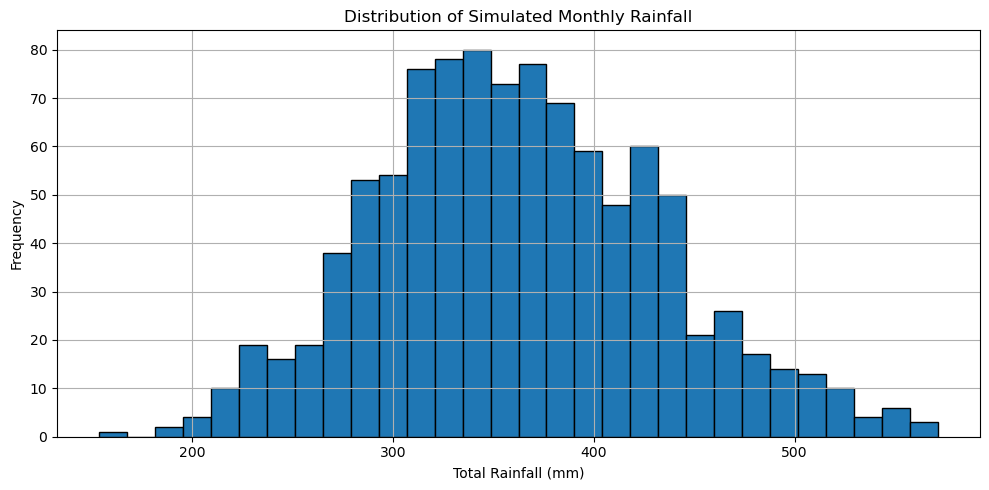

In [17]:
monthly_totals = rainfall_samples.sum(axis=1)

plt.figure(figsize=(10,5))

plt.hist(
    monthly_totals,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Simulated Monthly Rainfall")
plt.xlabel("Total Rainfall (mm)")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation

Each line in the previous figure represents one possible future rainfall pattern. Instead of assuming that rainfall will exactly equal its historical average, HydroSense evaluates many plausible futures. This allows irrigation schedules to become **risk-aware** rather than deterministic. 

---

## Single Zone Irrigation Scheduling

The next objective is to determine **how much irrigation** should be applied to a single field. 

The scheduling algorithm considers:

- rainfall,
- evapotranspiration,
- drainage,
- current soil moisture,
- crop requirements.

Water is only applied when the predicted soil moisture falls below the minimum acceptable level. 

In [18]:
from src.optimization import schedule_zone

In [19]:
zone = crop.iloc[0]

zone

zone_id                 Zone_A
crop_type               tomato
area_m2                    120
min_moisture_pct            22
target_moisture_pct         33
field_capacity_pct          41
drainage_coefficient      0.18
Name: 0, dtype: object

In [20]:
dry_rainfall = rainfall * 0.15

irrigation_schedule, moisture_profile = schedule_zone(
    S0=30,  # initial moisture
    rainfall=dry_rainfall,
    temp=temp,
    wind=wind,
    solar=solar,
    humidity=humidity,
    min_moisture=zone["min_moisture_pct"],
    target_moisture=zone["target_moisture_pct"],
    field_capacity=zone["field_capacity_pct"],
    drainage_coeff=zone["drainage_coefficient"],
    efficiency=0.90
)

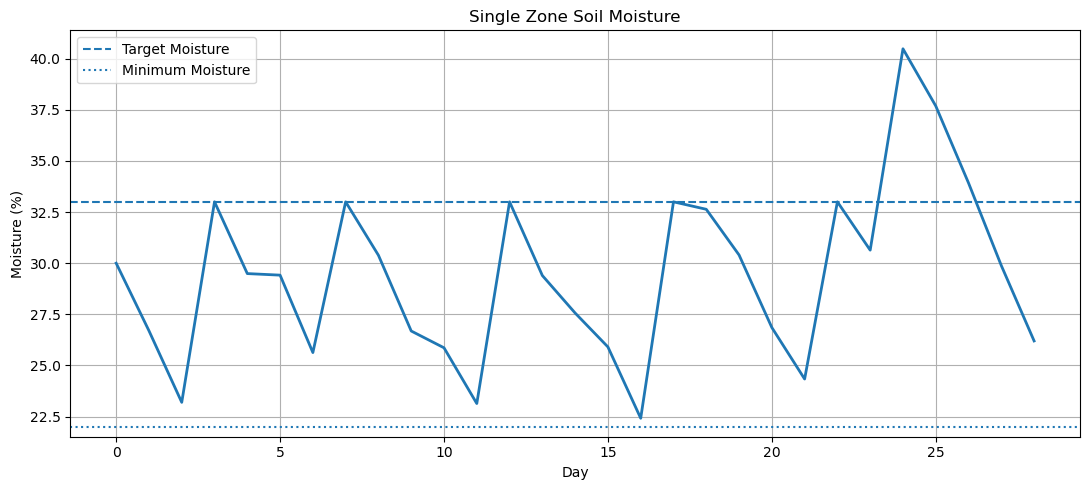

In [21]:
plt.figure(figsize=(11,5))

plt.plot(
    moisture_profile,
    linewidth=2
)

plt.axhline(
    zone["target_moisture_pct"],
    linestyle="--",
    label="Target Moisture"
)

plt.axhline(
    zone["min_moisture_pct"],
    linestyle=":",
    label="Minimum Moisture"
)

plt.title("Single Zone Soil Moisture")

plt.xlabel("Day")
plt.ylabel("Moisture (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
print(type(irrigation_schedule))
print(irrigation_schedule)
print("Length:", len(irrigation_schedule))
print("Sum:", np.sum(irrigation_schedule))
print("Max:", np.max(irrigation_schedule))

<class 'numpy.ndarray'>
[ 0.          0.         14.99666667  0.          0.          0.
 12.22277778  0.          0.          0.          0.         13.59982759
  0.          0.          0.          0.         15.02777778  0.
  0.          0.          0.         12.43888889  0.          0.
  0.          0.          0.          0.        ]
Length: 28
Sum: 68.285938697318
Max: 15.027777777777764


In [23]:
print("Minimum moisture:", np.min(moisture_profile))
print("Maximum moisture:", np.max(moisture_profile))
print("Target:", zone["target_moisture_pct"])
print("Minimum allowed:", zone["min_moisture_pct"])

Minimum moisture: 22.41950000000001
Maximum moisture: 40.4805
Target: 33
Minimum allowed: 22


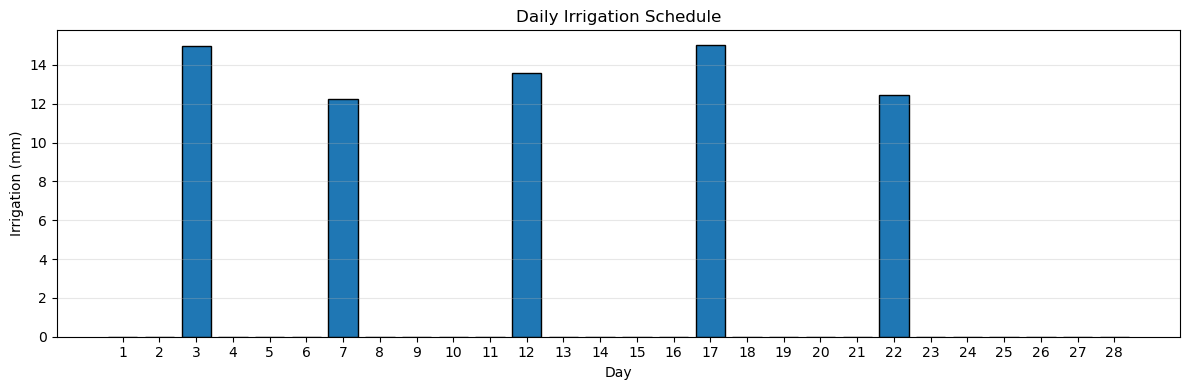

Total irrigation: 68.285938697318


In [24]:
import matplotlib.pyplot as plt
import numpy as np

days = np.arange(1, len(irrigation_schedule) + 1)

plt.figure(figsize=(12,4))

plt.bar(
    days,
    irrigation_schedule,
    edgecolor="black"
)

plt.xticks(days)
plt.xlabel("Day")
plt.ylabel("Irrigation (mm)")
plt.title("Daily Irrigation Schedule")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Total irrigation:", irrigation_schedule.sum())

### Interpretation of the Irrigation Schedule

The irrigation schedule shows that HydroSense does **not** apply water continuously. Instead, irrigation events only occur on days where the predicted soil moisture would otherwise fall below the minimum allowable threshold.

This demonstrates one of the primary objectives of precision irrigation:

- maintain adequate soil moisture,
- minimise unnecessary water use,
- react only when environmental conditions require intervention.

Notice that the amount of irrigation applied varies between irrigation events. This is because the scheduler calculates the exact amount of water required to restore the soil close to the target moisture level while accounting for irrigation efficiency losses. 

---

## Multi-Zone Irrigation Optimisation

Large farms rarely consist of a single uniform field. Different irrigation zones often contain different crops, soil characteristics and drainage behaviour. As a result, every zone requires its own irrigation strategy. HydroSense extends the single-zone scheduler by independently evaluating each zone before combining the results into a complete farm-wide irrigation plan. This allows water to be distributed where it is needed most instead of applying the same amount across the entire farm. 

The following simulation generates irrigation schedules for every zone using the same weather conditions but different crop parameters.

In [25]:
from src.optimization import (
    schedule_all_zones,
    efficiency_report
)

In [26]:
initial_conditions = {
    zone_id: 30
    for zone_id in crop["zone_id"]
}

initial_conditions

{'Zone_A': 30, 'Zone_B': 30, 'Zone_C': 30}

In [27]:
all_schedules, all_moistures = schedule_all_zones(
    S0_dict=initial_conditions,
    rainfall=dry_rainfall,
    temp=temp,
    wind=wind,
    solar=solar,
    humidity=humidity,
    params_df=crop,
    efficiency=0.90
)

### Evaluating Irrigation Performance

After generating irrigation schedules for all zones, HydroSense summarizes their performance using several engineering metrics. These metrics allow different irrigation strategies to be compared objectively and help identify zones requiring additional water management.

In [28]:
report = pd.DataFrame(
    efficiency_report(
        all_schedules,
        all_moistures,
        crop
    )
)

In [29]:
print("Summary Statistics")
print("-" * 40)

print(f"Total irrigation applied : {report['total_irrigation_mm'].sum():.2f} mm")
print(f"Average irrigation/zone  : {report['total_irrigation_mm'].mean():.2f} mm")
print(f"Total stress days        : {report['stress_days'].sum()}")
print(f"Average moisture         : {report['mean_moisture_pct'].mean():.2f}%")

Summary Statistics
----------------------------------------
Total irrigation applied : 202.04 mm
Average irrigation/zone  : 67.35 mm
Total stress days        : 0
Average moisture         : 29.23%


#### Interpretation

The performance table summarizes the behaviour of the optimisation algorithm across all irrigation zones. Lower irrigation volumes indicate efficient water use, while fewer stress days suggest that soil moisture remained above the minimum acceptable threshold for longer periods. These indicators provide a quantitative basis for evaluating irrigation performance.

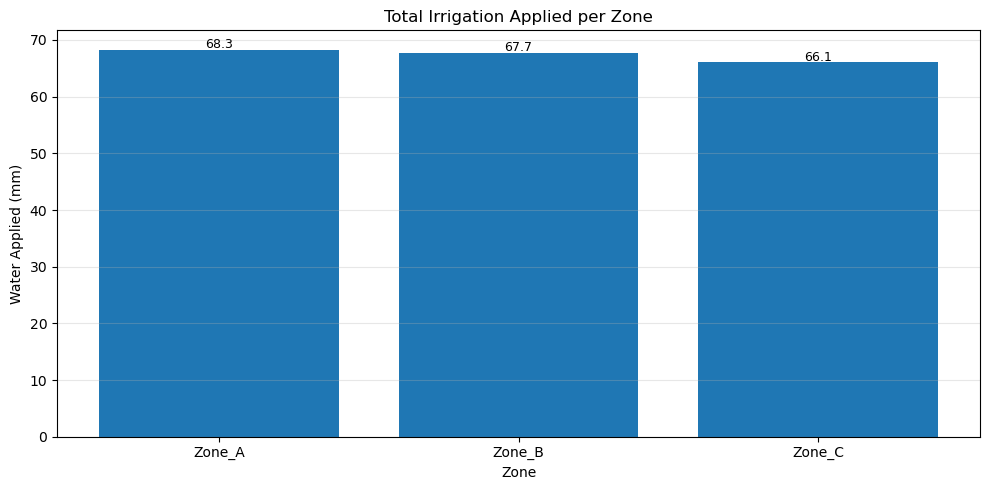

In [30]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    report["zone"],
    report["total_irrigation_mm"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=9
    )

plt.title("Total Irrigation Applied per Zone")
plt.xlabel("Zone")
plt.ylabel("Water Applied (mm)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The figure compares the total irrigation supplied to each crop zone during the simulation period. Zones receiving larger irrigation volumes either experienced greater evapotranspiration losses or required higher soil moisture targets to support healthy crop growth. 

In [31]:
print(report)

print("\nStress days:")
print(report["stress_days"])

print("\nUnique values:")
print(report["stress_days"].unique())

     zone  total_irrigation_mm  days_irrigated  stress_days  \
0  Zone_A                68.29               5            0   
1  Zone_B                67.69               5            0   
2  Zone_C                66.06               5            0   

   mean_moisture_pct  max_moisture_pct  min_moisture_pct  
0              29.42             40.48             22.42  
1              30.70             39.95             24.23  
2              27.57             38.48             20.42  

Stress days:
0    0
1    0
2    0
Name: stress_days, dtype: int64

Unique values:
[0]


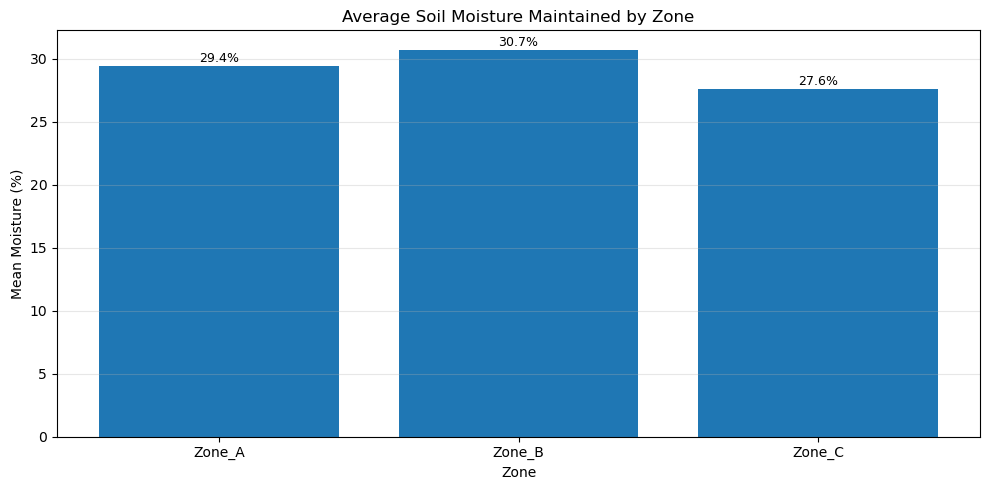

In [32]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    report["zone"],
    report["mean_moisture_pct"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("Average Soil Moisture Maintained by Zone")
plt.xlabel("Zone")
plt.ylabel("Mean Moisture (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Unlike the previous irrigation chart, this figure highlights the average operating moisture maintained in each irrigation zone throughout the simulation. Although the zones received different irrigation amounts, the optimisation algorithm successfully kept soil moisture within acceptable limits for all crops. The absence of crop stress days indicates that irrigation was applied early enough to prevent moisture from falling below the minimum allowable threshold. 

---

## Overall Irrigation Performance Dashboard

The previous analyses examined irrigation behaviour from individual perspectives.

This final dashboard summarises the optimisation results using three complementary performance indicators:

- **Total Irrigation Applied** – overall water supplied to each zone.
- **Average Soil Moisture** – long-term moisture maintained throughout the simulation.
- **Days Irrigated** – frequency of irrigation events.

Together, these indicators provide a concise overview of HydroSense's irrigation performance across the entire farm. 

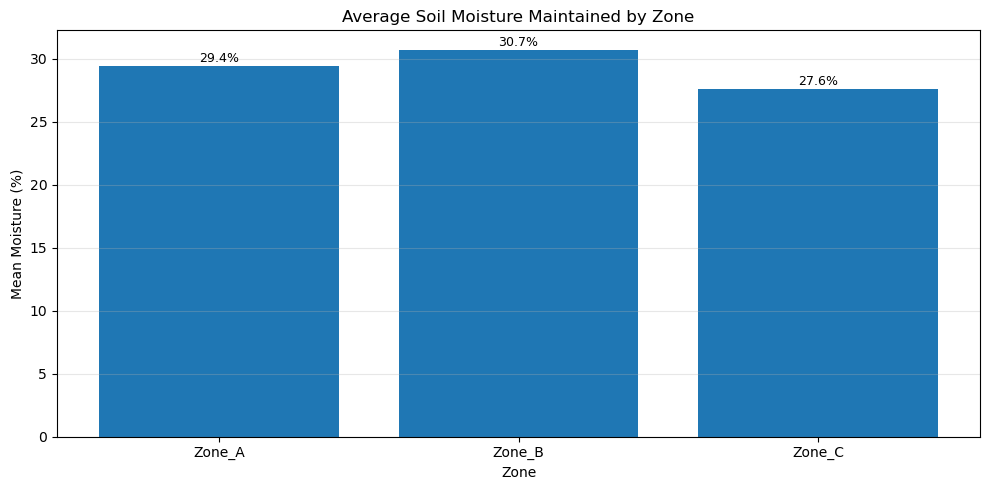

In [33]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    report["zone"],
    report["mean_moisture_pct"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("Average Soil Moisture Maintained by Zone")
plt.xlabel("Zone")
plt.ylabel("Mean Moisture (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The optimisation algorithm maintained average soil moisture within a healthy operating range for all irrigation zones. Although each zone received different amounts of irrigation, the resulting average moisture levels remained relatively consistent. This demonstrates that the scheduler adapts irrigation according to crop requirements rather than applying a fixed amount of water to every zone. Maintaining stable soil moisture while avoiding unnecessary irrigation is a key objective of precision agriculture. 

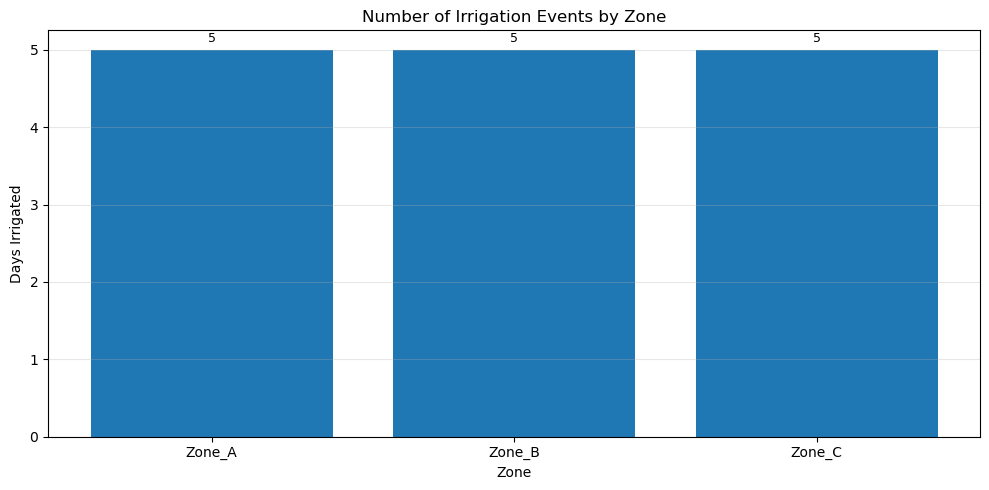

In [34]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    report["zone"],
    report["days_irrigated"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=9
    )

plt.title("Number of Irrigation Events by Zone")
plt.xlabel("Zone")
plt.ylabel("Days Irrigated")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scheduler irrigated each zone only when soil moisture was predicted to fall below the minimum acceptable threshold. Rather than applying water every day, HydroSense concentrated irrigation into a small number of carefully timed events. This behaviour reduces unnecessary water use while maintaining healthy crop conditions throughout the simulation period. The fact that every zone required a similar number of irrigation events suggests that the optimisation algorithm responded consistently to the simulated weather conditions. 

In [35]:
summary = pd.DataFrame({
    "Metric": [
        "Total Water Applied (mm)",
        "Average Water per Zone (mm)",
        "Average Soil Moisture (%)",
        "Total Irrigation Events",
        "Total Crop Stress Days"
    ],
    "Value": [
        round(report["total_irrigation_mm"].sum(), 2),
        round(report["total_irrigation_mm"].mean(), 2),
        round(report["mean_moisture_pct"].mean(), 2),
        int(report["days_irrigated"].sum()),
        int(report["stress_days"].sum())
    ]
})

summary

,Metric,Value
0,Total Water Applied (mm),202.04
1,Average Water per Zone (mm),67.35
2,Average Soil Moisture (%),29.23
3,Total Irrigation Events,15.00
4,Total Crop Stress Days,0.00


## Final Conclusions

This notebook demonstrated how numerical simulation and optimisation techniques can be integrated into an intelligent irrigation management system.

Across the workflow, HydroSense successfully:

- modelled soil moisture dynamics using water balance equations,
- simulated moisture changes using both Euler and Runge–Kutta numerical methods,
- incorporated rainfall uncertainty through Monte Carlo simulation,
- generated adaptive irrigation schedules for individual crop zones,
- extended the scheduling process to multiple zones, and
- evaluated irrigation performance using quantitative engineering metrics.

The optimisation results indicate that irrigation was applied only when necessary, maintaining soil moisture above the minimum allowable threshold while avoiding crop stress throughout the simulation period. Overall, the notebook illustrates how scientific computing techniques can be combined with agricultural data to support more efficient, sustainable and data-driven irrigation management. 